In [ ]:
import pandas as pd
import numpy as np

import missingno as miss
import matplotlib.pyplot as plt

# 1. Load Data

In [ ]:
df = pd.read_csv("../data/adult_income.csv")

# 2. Check Data Info.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


drop non usefull columns

In [ ]:
df = df.drop('fnlwgt', axis=1)

# 3. Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(3465)

In [ ]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8502,17,?,10th,6,Never-married,?,Own-child,White,Female,0,0,15,United-States,<=50K
31869,17,?,10th,6,Never-married,?,Own-child,White,Female,0,0,15,United-States,<=50K
5755,17,?,10th,6,Never-married,?,Own-child,White,Female,0,0,20,United-States,<=50K
25725,17,?,10th,6,Never-married,?,Own-child,White,Female,0,0,20,United-States,<=50K
31856,17,?,10th,6,Never-married,?,Own-child,White,Female,0,0,20,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29570,73,?,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,0,15,United-States,<=50K
21192,90,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
31218,90,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
6227,90,Private,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K


In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# 4. Check Missing Values

In [ ]:
df = df.replace('?', np.nan)

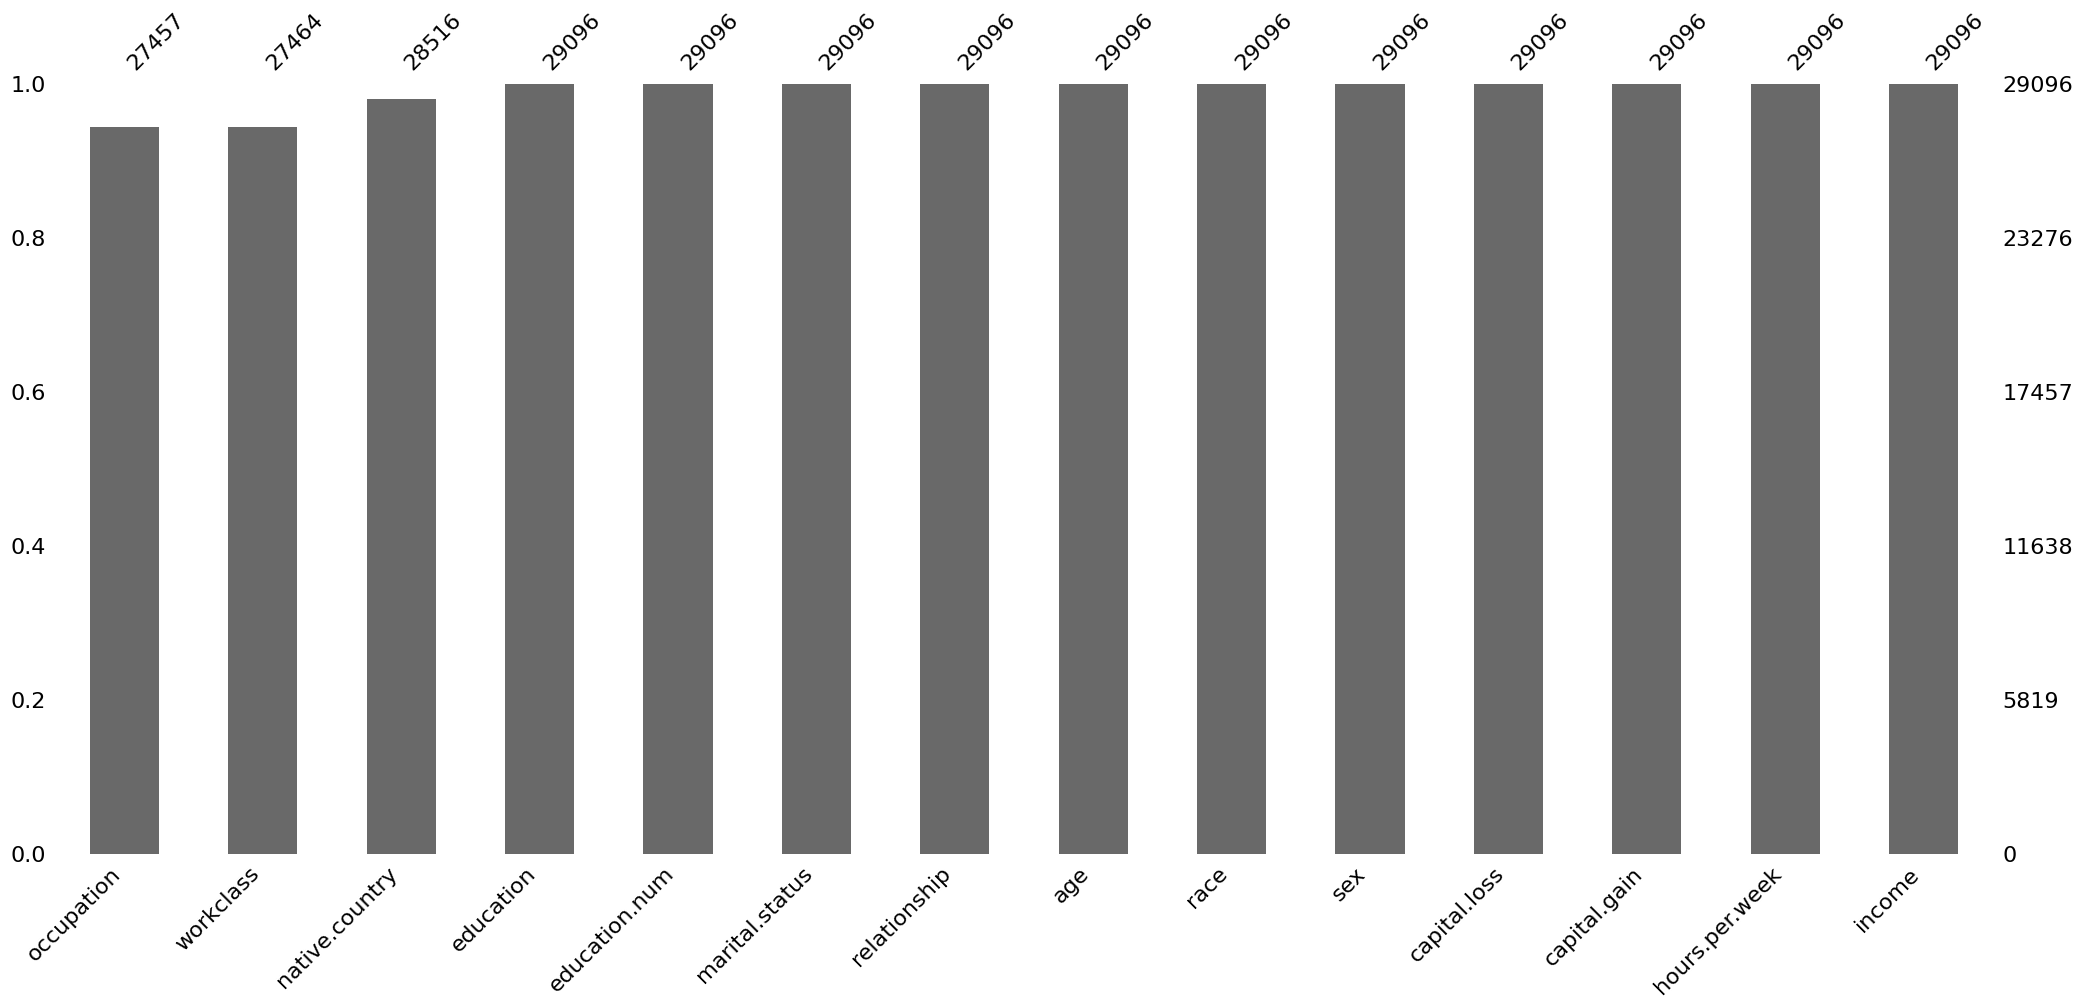

                Missing Count  Missing %
occupation               1639       5.63
workclass                1632       5.61
native.country            580       1.99
age                         0       0.00
education.num               0       0.00
education                   0       0.00
marital.status              0       0.00
relationship                0       0.00
sex                         0       0.00
race                        0       0.00
capital.gain                0       0.00
capital.loss                0       0.00
hours.per.week              0       0.00
income                      0       0.00

Total rows with missing values: 2192, 7.53%


In [ ]:
ax = miss.bar(df, sort='ascending')
plt.show()

# A missing summery with values and rates
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

rows_with_missing = df.isnull().any(axis=1).sum()

print(missing_summary)
print(f'\nTotal rows with missing values: {rows_with_missing}, {(rows_with_missing/len(df)*100).round(2)}%')

Checking values for the columns that contain missing values

In [ ]:
df['occupation'].value_counts()

occupation
Prof-specialty       3885
Exec-managerial      3719
Adm-clerical         3340
Craft-repair         3298
Sales                3270
Other-service        2996
Machine-op-inspct    1702
Transport-moving     1445
Handlers-cleaners    1179
Farming-fishing       962
Tech-support          874
Protective-serv       631
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [ ]:
df['workclass'].value_counts()

workclass
Private             19621
Self-emp-not-inc     2473
Local-gov            2040
State-gov            1272
Self-emp-inc         1091
Federal-gov           946
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [ ]:
df['native.country'].value_counts()

native.country
United-States                 25721
Mexico                          633
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        62
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                           29
France       

Missing values distribution vs Income

In [ ]:
categorical_cols = ['workclass', 'occupation', 'native.country']

for col in categorical_cols:
    print(f'\n{col}')
    display(
        pd.crosstab(
            df[col].isna(),
            df['income'],
            normalize='index'
        ) * 100
    )


workclass


income,<=50K,>50K
workclass,,
False,74.435625,25.564375
True,88.419118,11.580882



occupation


income,<=50K,>50K
occupation,,
False,74.429107,25.570893
True,88.468578,11.531422



native.country


income,<=50K,>50K
native.country,,
False,75.224435,24.775565
True,75.000000,25.000000


Since the missing values have different distributions across the target variable, they will not be dropped. Instead, they will be categorized as "Unknown" or "Other."

In [ ]:
df['native.country'] = df['native.country'].fillna('Unknown')
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')

Final Check for Missing Values

In [ ]:
df.isna().sum()

age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

# 5. Check Inconsistent Categorical Values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29096 entries, 0 to 32559
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29096 non-null  int64 
 1   workclass       29096 non-null  object
 2   education       29096 non-null  object
 3   education.num   29096 non-null  int64 
 4   marital.status  29096 non-null  object
 5   occupation      29096 non-null  object
 6   relationship    29096 non-null  object
 7   race            29096 non-null  object
 8   sex             29096 non-null  object
 9   capital.gain    29096 non-null  int64 
 10  capital.loss    29096 non-null  int64 
 11  hours.per.week  29096 non-null  int64 
 12  native.country  29096 non-null  object
 13  income          29096 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.3+ MB


Checking the unique values for each categorical column

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(sorted(df[col].unique()))


workclass
['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Unknown', 'Without-pay']

education
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital.status
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation
['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving', 'Unknown']

relationship
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

sex
['Female', 'Male']

native.country
['Cambodia', 'Canada', 'China', 'Columbia'

Checking Education Level Encoding

In [ ]:
df[['education', 'education.num']].drop_duplicates().sort_values('education.num')

,education,education.num
1106,Preschool,1
26,1st-4th,2
27,5th-6th,3
3,7th-8th,4
197,9th,5
6,10th,6
16,11th,7
178,12th,8
0,HS-grad,9
2,Some-college,10


Since the `education` column is correctly encoded without any errors, it will be dropped, and `education.num` will be used instead.

In [ ]:
df = df.drop('education', axis=1)

# 6. Final Check

In [ ]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100),
    "unique": df.nunique(),
}).sort_values(["missing", "unique"], ascending=[False, True])

display(audit)

print("Duplicated rows:", df.duplicated().sum())

,dtype,missing,missing_%,unique
sex,object,0,0.0,2
income,object,0,0.0,2
race,object,0,0.0,5
relationship,object,0,0.0,6
marital.status,object,0,0.0,7
workclass,object,0,0.0,9
occupation,object,0,0.0,15
education.num,int64,0,0.0,16
native.country,object,0,0.0,42
age,int64,0,0.0,73


Duplicated rows: 0


# 7. Save Cleaned Data

In [ ]:
df.to_csv('../data/cleaned_adult_income.csv', index=False)